# LOAD LIBRARIES

In [14]:
import os
import math
import numpy as np
import scipy
import pandas as pd # pandas allows to do a lot of basic data manipulation such as loading csv data files
from datetime import datetime
import matplotlib.pyplot as plt # matplotlib is a basic ploting library of Python
import scipy.stats as stats
import sys
import matplotlib.dates as mdates
from sklearn.linear_model import HuberRegressor
from sklearn.metrics import r2_score

# READ DATA

## STATION DATA

,g,pa,ppfd,prec,rh,swc_0.05,swc_0.15,swc_0.3,swc_0.05_soilvue,swc_0.1_soilvue,...,ts_0.05_soilvue,ts_0.1_soilvue,ts_0.2_soilvue,ts_0.3_soilvue,ts_0.4_soilvue,ts_0.5_soilvue,sw_in,sw_out,lw_in,lw_out
TIMESTAMP_END,,,,,,,,,,,,,,,,,,,,,
2023-11-18 23:30:00+01:00,-4.175582,95.558519,NaN,0.000,78.492593,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
2023-11-19 00:00:00+01:00,-3.701263,95.507667,NaN,0.000,79.276667,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
2023-11-19 00:30:00+01:00,-2.279430,95.470000,NaN,0.221,84.429999,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
2023-11-19 01:00:00+01:00,-0.730810,95.467667,NaN,0.153,87.846667,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
2023-11-19 01:30:00+01:00,0.000000,95.466667,NaN,0.204,89.633334,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 21:30:00+01:00,-25.106403,95.121000,0.0,0.017,82.716668,27.983877,29.086370,24.730949,18.070884,17.896644,...,17.802203,18.252201,18.110617,17.670830,16.863900,16.296347,0.0,0.0,353.321647,392.177650
2025-06-04 22:00:00+01:00,-23.907052,95.134000,0.0,0.017,82.700000,27.981393,29.086370,24.709643,18.329227,18.018475,...,17.638945,18.094945,18.042643,17.669967,16.876580,16.297180,0.0,0.0,365.498643,392.441257
2025-06-04 22:30:00+01:00,-22.316862,95.139333,0.0,0.034,84.423333,27.982679,29.086370,24.707201,18.053377,18.021240,...,17.515017,17.955672,17.975648,17.650989,16.876580,16.302190,0.0,0.0,368.483990,391.171820


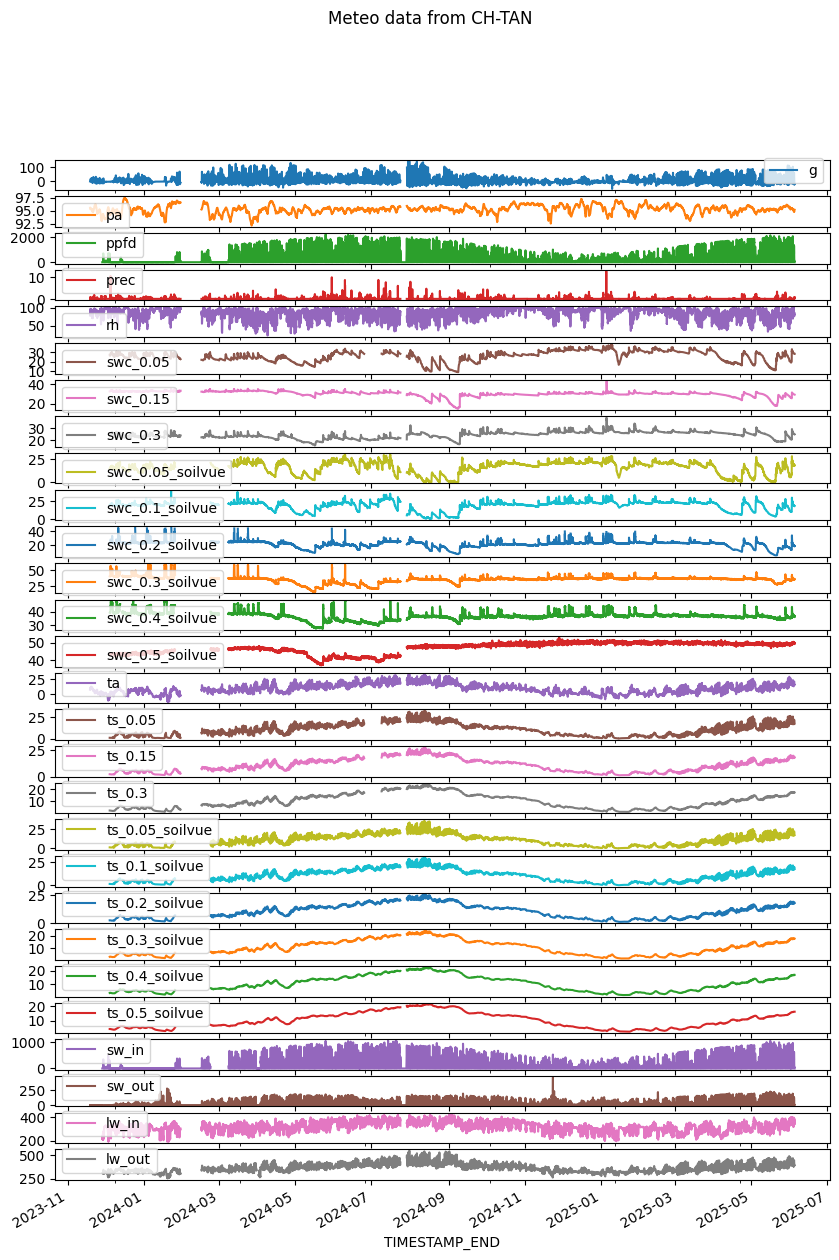

In [15]:
meteo = pd.read_csv('..\\..\\data\\METEO\\CH-TAN_2023-25_ALL_METEO_meteoscreening_diive.csv')
meteo['TIMESTAMP_END'] = pd.to_datetime(meteo['TIMESTAMP_END'], format='%Y-%m-%d %H:%M:%S')
meteo.set_index('TIMESTAMP_END', inplace=True)
meteo.index = meteo.index.tz_localize('Etc/GMT-1')
meteo.plot(subplots=True, x_compat=True, figsize=(10, 15), title='Meteo data from CH-TAN');
meteo

## METEOSWISS DATA

- tre200s0 --> TA at 2 m in °C
- ure200s0 --> RH at 2m
- prestas0 --> PA in hPa
- fve010z0 --> WS in m/s vectorial mean
- fkl010z0 --> WS in m/s scalar mean
- dkl010z0 --> WD in degrees
- rre150z0 --> P in mm
- gre000z0 --> global radiation in w/m2
- ods000z0 --> diffuse radiation in w/m2
- oli000z0 --> LW_IN in w/m2
- olo000z0 --> LW_OUT in w/m2
- osr000z0 --> SW_OUT in w/m2

,TA,RH,PA,PREC,SW_IN,SW_OUT,LW_IN,LW_OUT
timestamp,,,,,,,,
2023-11-01 00:00:00+01:00,8.000000,79.800000,95.090000,0.0,1.000000,-6.000000,271.000000,329.000000
2023-11-01 00:30:00+01:00,8.633333,75.733333,95.070000,0.0,1.000000,-6.000000,272.000000,330.666667
2023-11-01 01:00:00+01:00,8.266667,76.433333,95.053333,0.0,1.666667,-6.000000,272.000000,333.000000
2023-11-01 01:30:00+01:00,6.966667,82.900000,95.046667,0.0,2.000000,-6.000000,269.666667,325.333333
2023-11-01 02:00:00+01:00,5.666667,88.566667,95.033333,0.0,2.333333,-6.000000,266.000000,319.666667
...,...,...,...,...,...,...,...,...
2025-06-05 22:00:00+01:00,15.833333,84.166667,95.236667,0.0,0.333333,-4.000000,366.333333,388.333333
2025-06-05 22:30:00+01:00,15.733333,83.833333,95.193333,0.0,0.333333,-4.000000,368.000000,387.666667
2025-06-05 23:00:00+01:00,16.200000,78.066667,95.170000,0.0,0.333333,-4.000000,356.333333,386.000000


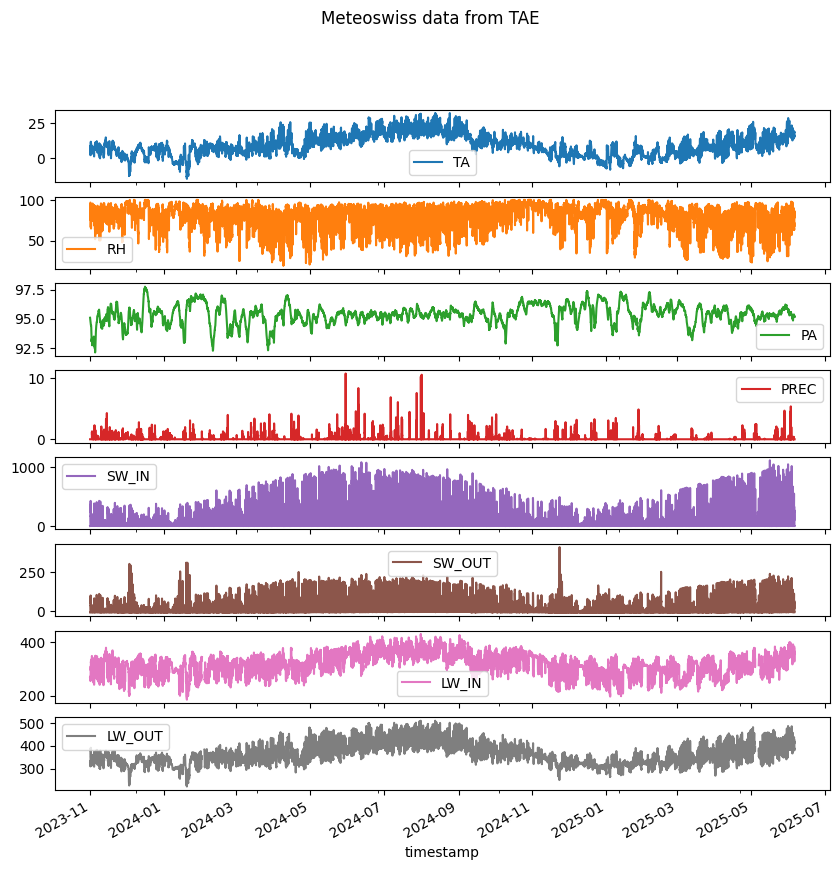

In [16]:
meteoswiss = pd.read_csv('..\\..\\data\METEO\\meteoswiss_TAE_meteo_2020-2029.csv', delimiter=';')
meteoswiss_2025 = pd.read_csv('..\\..\\data\METEO\\meteoswiss_TAE_meteo_2025.csv', delimiter=';')
meteoswiss = pd.concat([meteoswiss, meteoswiss_2025], ignore_index=True)
rename_dict = {
    'reference_timestamp': 'timestamp',
    'tre200s0': 'TA',
    'ure200s0': 'RH',
    'prestas0': 'PA',
    'rre150z0': 'PREC',
    'gre000z0': 'SW_IN',
    'osr000z0': 'SW_OUT',
    'oli000z0': 'LW_IN',
    'olo000z0': 'LW_OUT',
}
meteoswiss.rename(columns=rename_dict, inplace=True)
meteoswiss = meteoswiss[[col for col in rename_dict.values()]]
meteoswiss['timestamp'] = pd.to_datetime(meteoswiss['timestamp'], format='%d.%m.%Y %H:%M')
meteoswiss.set_index('timestamp', inplace=True)
# Convert meteoswiss timestamps to UTC+1
meteoswiss.index = meteoswiss.index.tz_localize('UTC').tz_convert('Etc/GMT-1')

# Change unit for atmospheric pressure from hPa to kgPa
meteoswiss['PA'] = meteoswiss['PA'] / 10.0  # Convert hPa to kPa

# Restrict to the period of interest
start_date = '2023-11-01'
end_date = '2025-06-05'
meteoswiss = meteoswiss[start_date:end_date]

# Resample 10-min to 30-min, summing 'PREC' and averaging other columns
meteoswiss = meteoswiss.resample('30min', label='right', closed='right').agg({
    'TA': 'mean',
    'RH': 'mean',
    'PA': 'mean',
    'PREC': 'sum',
    'SW_IN': 'mean',
    'SW_OUT': 'mean',
    'LW_IN': 'mean',
    'LW_OUT': 'mean'
})

meteoswiss.plot(subplots=True, x_compat=True, figsize=(10, 10), title='Meteoswiss data from TAE');
meteoswiss

Linear model to calculate ppfd from sw_in because it was not measured by Meteoswiss

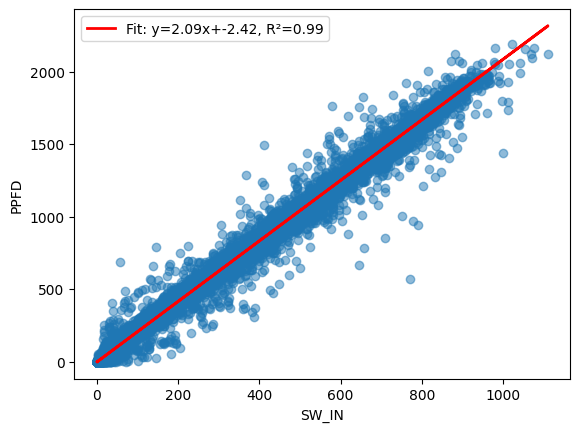

In [17]:
# Align the two series by index (inner join keeps only common timestamps)
df = meteoswiss[['SW_IN']].join(meteo[['ppfd']], how='inner')

# Drop NaNs
df = df.dropna()

x = df['SW_IN'].values.reshape(-1, 1)
y = df['ppfd'].values

# Fit robust regression
model = HuberRegressor().fit(x, y)
y_pred = model.predict(x)

# Equation and R²
slope = model.coef_[0]
intercept = model.intercept_
r2 = r2_score(y, y_pred)

# Plot
plt.scatter(x, y, alpha=0.5)
plt.plot(x, y_pred, color="red", lw=2, label=f"Fit: y={slope:.2f}x+{intercept:.2f}, R²={r2:.2f}")
plt.xlabel('SW_IN')
plt.ylabel('PPFD')
plt.legend()
plt.show()

# Create a new PPFD col using the linear model
meteoswiss['PPFD'] = model.predict(meteoswiss['SW_IN'].values.reshape(-1, 1))

## MERGE

In [18]:
meteo_merged = pd.merge(meteo, meteoswiss, left_index=True, right_index=True, how='outer')

meteo_merged

,g,pa,ppfd,prec,rh,swc_0.05,swc_0.15,swc_0.3,swc_0.05_soilvue,swc_0.1_soilvue,...,lw_out,TA,RH,PA,PREC,SW_IN,SW_OUT,LW_IN,LW_OUT,PPFD
2023-11-01 00:00:00+01:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,8.000000,79.800000,95.090000,0.0,1.000000,-6.000000,271.000000,329.000000,-0.334673
2023-11-01 00:30:00+01:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,8.633333,75.733333,95.070000,0.0,1.000000,-6.000000,272.000000,330.666667,-0.334673
2023-11-01 01:00:00+01:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,8.266667,76.433333,95.053333,0.0,1.666667,-6.000000,272.000000,333.000000,1.055954
2023-11-01 01:30:00+01:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,6.966667,82.900000,95.046667,0.0,2.000000,-6.000000,269.666667,325.333333,1.751268
2023-11-01 02:00:00+01:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,5.666667,88.566667,95.033333,0.0,2.333333,-6.000000,266.000000,319.666667,2.446582
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-05 22:00:00+01:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,15.833333,84.166667,95.236667,0.0,0.333333,-4.000000,366.333333,388.333333,-1.725301
2025-06-05 22:30:00+01:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,15.733333,83.833333,95.193333,0.0,0.333333,-4.000000,368.000000,387.666667,-1.725301
2025-06-05 23:00:00+01:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,16.200000,78.066667,95.170000,0.0,0.333333,-4.000000,356.333333,386.000000,-1.725301
2025-06-05 23:30:00+01:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,15.666667,82.233333,95.163333,0.0,0.666667,-4.333333,366.333333,387.000000,-1.029987


# COMPARE DATASETS

During winter time

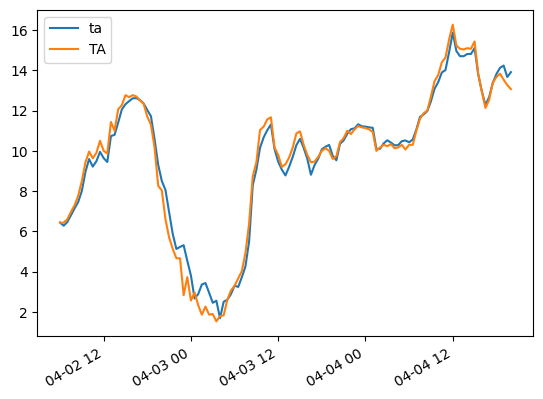

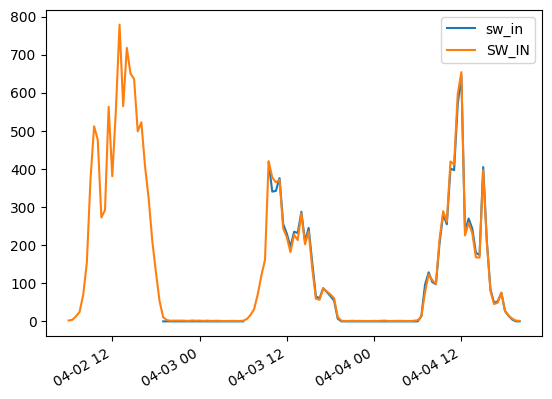

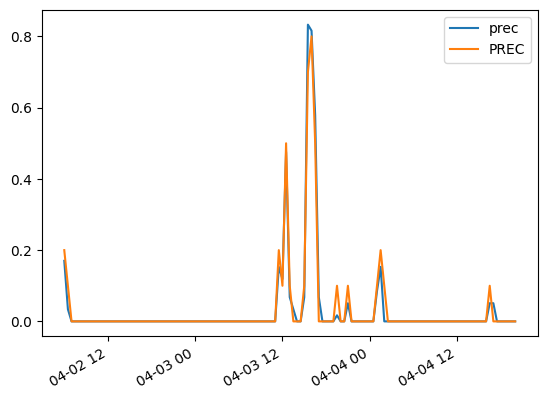

In [19]:
start_date = '2024-04-02 06:00'
end_date = '2024-04-04 20:00'
meteo_merged[start_date:end_date][['ta', 'TA']].plot(x_compat=True);
meteo_merged[start_date:end_date][['sw_in', 'SW_IN']].plot(x_compat=True);
meteo_merged[start_date:end_date][['prec', 'PREC']].plot(x_compat=True);

During summer time

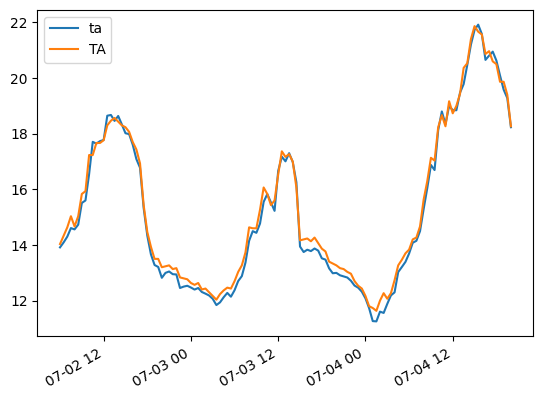

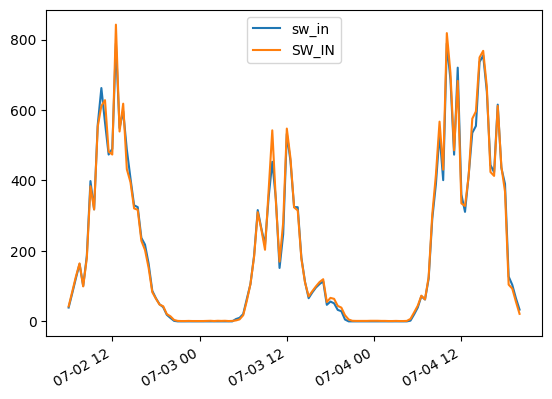

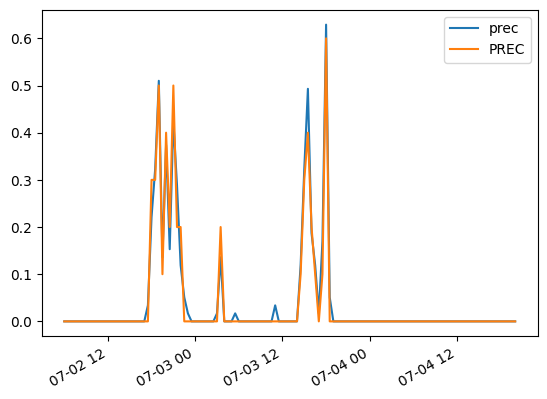

In [20]:
start_date = '2024-07-02 06:00'
end_date = '2024-07-04 20:00'
meteo_merged[start_date:end_date][['ta', 'TA']].plot(x_compat=True);
meteo_merged[start_date:end_date][['sw_in', 'SW_IN']].plot(x_compat=True);
meteo_merged[start_date:end_date][['prec', 'PREC']].plot(x_compat=True);

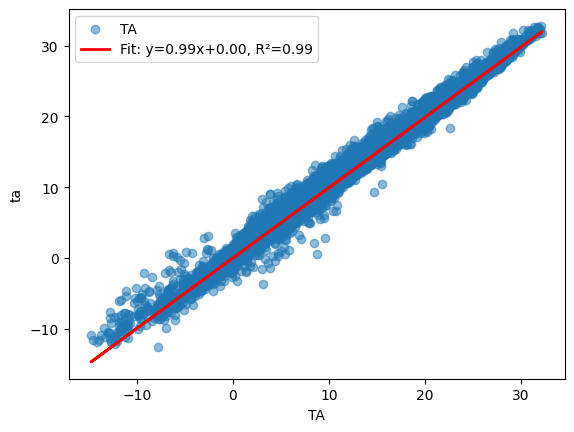

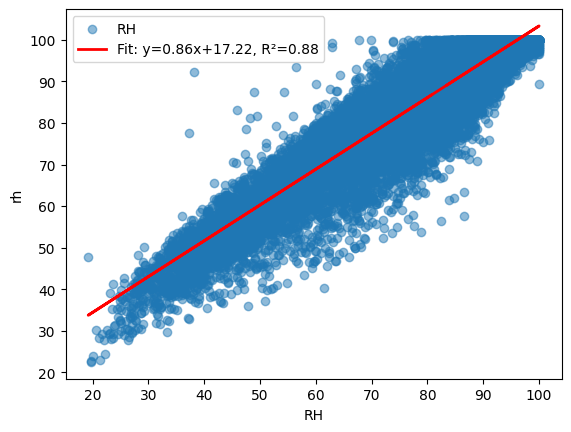

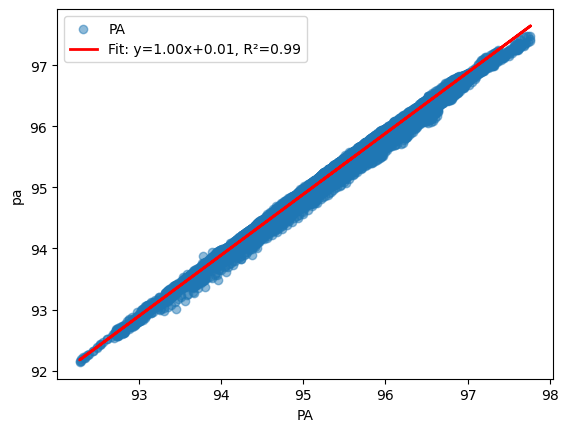

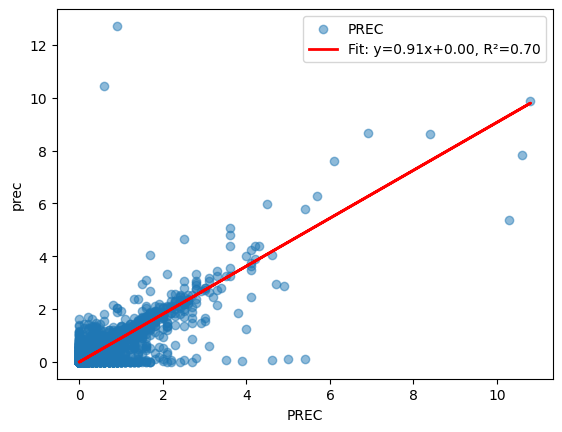

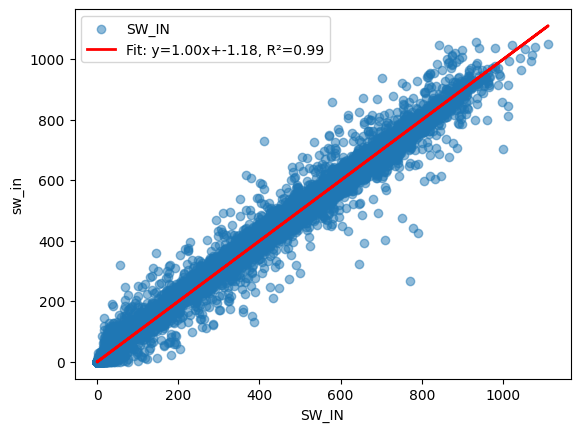

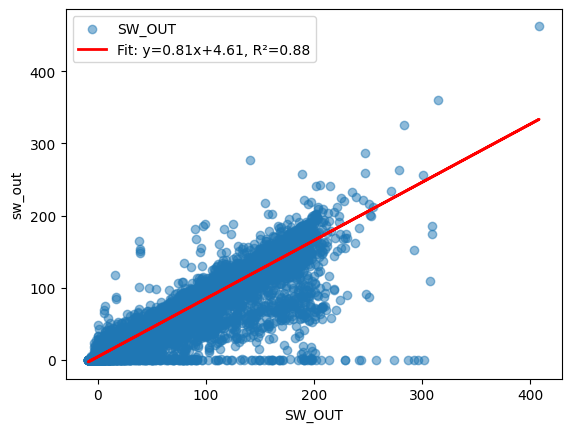

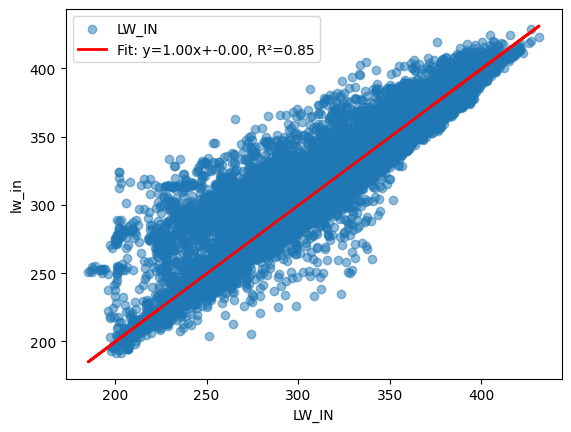

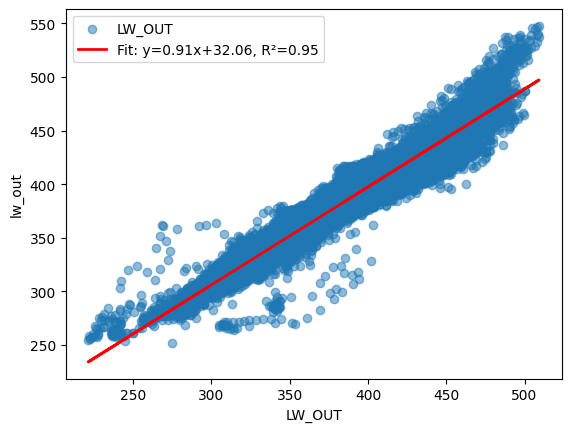

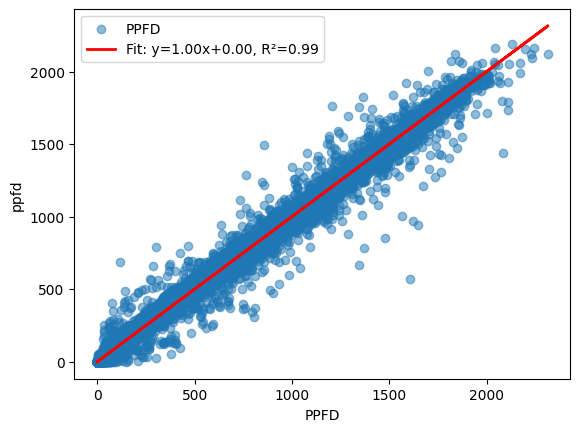

In [21]:
meteoswiss_vars = meteoswiss.columns.tolist()

for var in meteoswiss_vars:
    x = meteo_merged[var].values.reshape(-1, 1)
    y = meteo_merged[var.lower()].values

    # Drop NaNs
    mask = ~np.isnan(x.flatten()) & ~np.isnan(y)
    x, y = x[mask], y[mask]

    # Fit robust regression
    model = HuberRegressor().fit(x, y)
    y_pred = model.predict(x)

    # Equation and R²
    slope = model.coef_[0]
    intercept = model.intercept_
    r2 = r2_score(y, y_pred)

    # Plot
    plt.scatter(x, y, alpha=0.5, label=var)
    plt.plot(x, y_pred, color="red", lw=2, label=f"Fit: y={slope:.2f}x+{intercept:.2f}, R²={r2:.2f}")
    plt.xlabel(var)
    plt.ylabel(var.lower())
    plt.legend()
    plt.show()

# GAP-FILLING

Remaining NaNs per column:
g                       1975
pa                         0
ppfd                       0
prec                       0
rh                         0
swc_0.05                3400
swc_0.15                2732
swc_0.3                 2732
swc_0.05_soilvue        3732
swc_0.1_soilvue         3733
swc_0.2_soilvue         3943
swc_0.3_soilvue         3732
swc_0.4_soilvue         3732
swc_0.5_soilvue         3732
ta                         0
ts_0.05                 3400
ts_0.15                 3400
ts_0.3                  3400
ts_0.05_soilvue         3366
ts_0.1_soilvue          3366
ts_0.2_soilvue          3366
ts_0.3_soilvue          3366
ts_0.4_soilvue          3366
ts_0.5_soilvue          3366
sw_in                      0
sw_out                     0
lw_in                     94
lw_out                    94
TA                         0
RH                         0
PA                         0
PREC                       0
SW_IN                      0
SW_OUT          

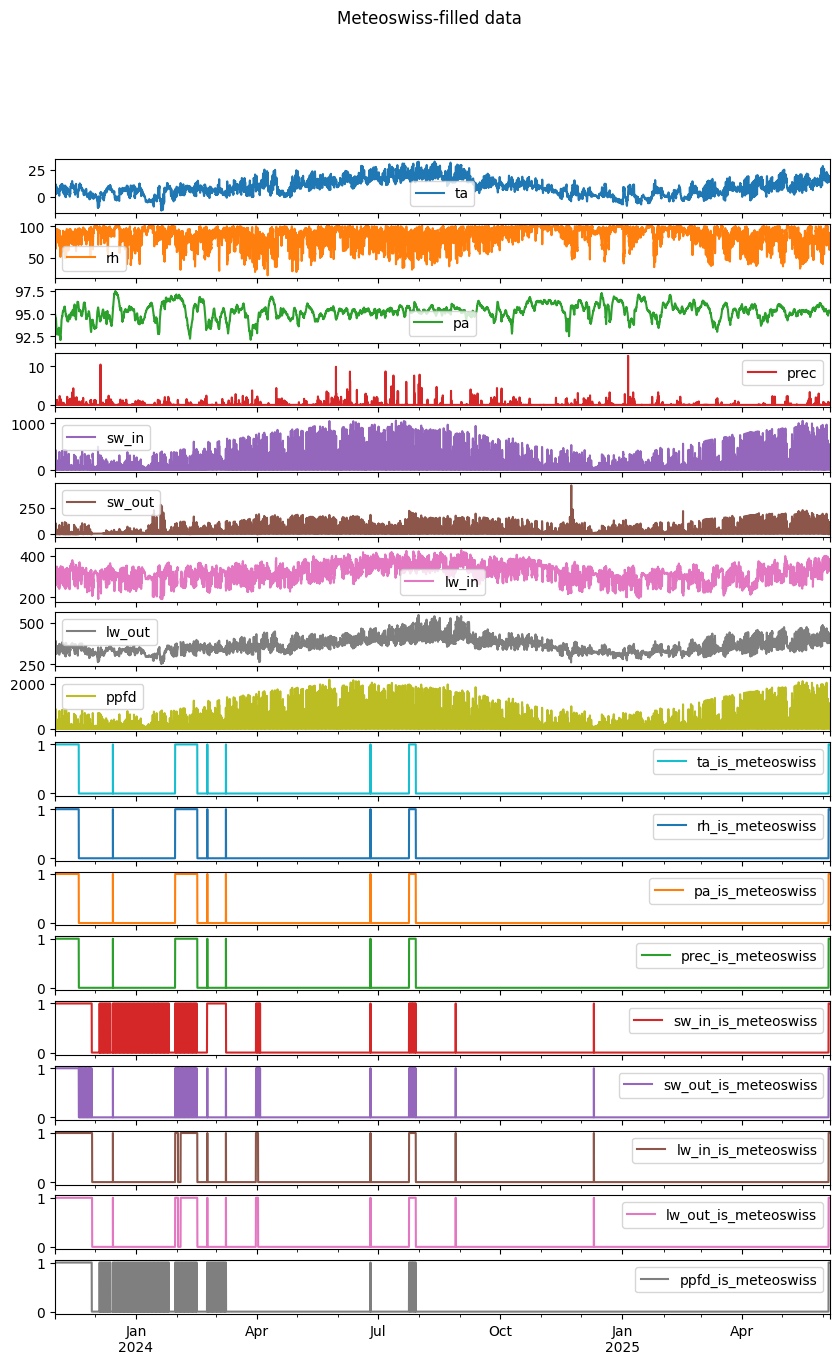

In [22]:
# Initialize a copy of the merged DataFrame to fill missing values
meteo_filled = meteo_merged.copy()

for var in meteoswiss_vars:
    lower_var = var.lower()
    flag_name = f"{lower_var}_is_meteoswiss"

    # Initialize flag column as False
    meteo_filled[flag_name] = 0

    # Values to fill (only where meteo_filled is NaN and meteoswiss has data)
    fill_mask = meteo_filled[lower_var].isna() & meteoswiss[var].notna()

    # Fill values
    meteo_filled.loc[fill_mask, lower_var] = meteoswiss.loc[fill_mask, var]

    # Mark fills
    meteo_filled.loc[fill_mask, flag_name] = 1

# Check remaining missing values
print("Remaining NaNs per column:")
print(meteo_filled.isna().sum())

# Select only the variables that exist in both datasets
cols_meteo_filled = [c.lower() for c in meteoswiss_vars]
flags = [c for c in meteo_filled.columns if c.endswith('_is_meteoswiss')]
to_plot = cols_meteo_filled + flags

meteo_filled[to_plot].plot(
    subplots=True, 
    figsize=(10, 15), 
    title='Meteoswiss-filled data'
);

# EXPORT GAP-FILLED DATA

In [23]:
meteo_filled.drop(columns=meteoswiss_vars, inplace=True)  # Drop the columns used for filling

# EXPORT GAP-FILLED DATA
output_file = '11.1_CH-TAN_meteo_meteoswiss-gapfilled.csv'
meteo_filled.reset_index(names='timestamp_end').to_csv(output_file, index=False)
print(f"Gap-filled data exported to {output_file}")

Gap-filled data exported to 11.1_CH-TAN_meteo_meteoswiss-gapfilled.csv


Formatting the 6 meteo variables that will be used for the level-1 flux calcs in EddyPro

,TIMESTAMP_1,LWin_1_1_1,Pa_1_1_1,PPFD_1_1_1,RH_1_1_1,SWin_1_1_1,Ta_1_1_1
2023-11-01 00:00:00+01:00,2023-11-01 0000,271.000000,95.090000,-0.334673,79.800000,1.000000,8.000000
2023-11-01 00:30:00+01:00,2023-11-01 0030,272.000000,95.070000,-0.334673,75.733333,1.000000,8.633333
2023-11-01 01:00:00+01:00,2023-11-01 0100,272.000000,95.053333,1.055954,76.433333,1.666667,8.266667
2023-11-01 01:30:00+01:00,2023-11-01 0130,269.666667,95.046667,1.751268,82.900000,2.000000,6.966667
2023-11-01 02:00:00+01:00,2023-11-01 0200,266.000000,95.033333,2.446582,88.566667,2.333333,5.666667
...,...,...,...,...,...,...,...
2025-06-05 22:00:00+01:00,2025-06-05 2200,366.333333,95.236667,-1.725301,84.166667,0.333333,15.833333
2025-06-05 22:30:00+01:00,2025-06-05 2230,368.000000,95.193333,-1.725301,83.833333,0.333333,15.733333
2025-06-05 23:00:00+01:00,2025-06-05 2300,356.333333,95.170000,-1.725301,78.066667,0.333333,16.200000
2025-06-05 23:30:00+01:00,2025-06-05 2330,366.333333,95.163333,-1.029987,82.233333,0.666667,15.666667


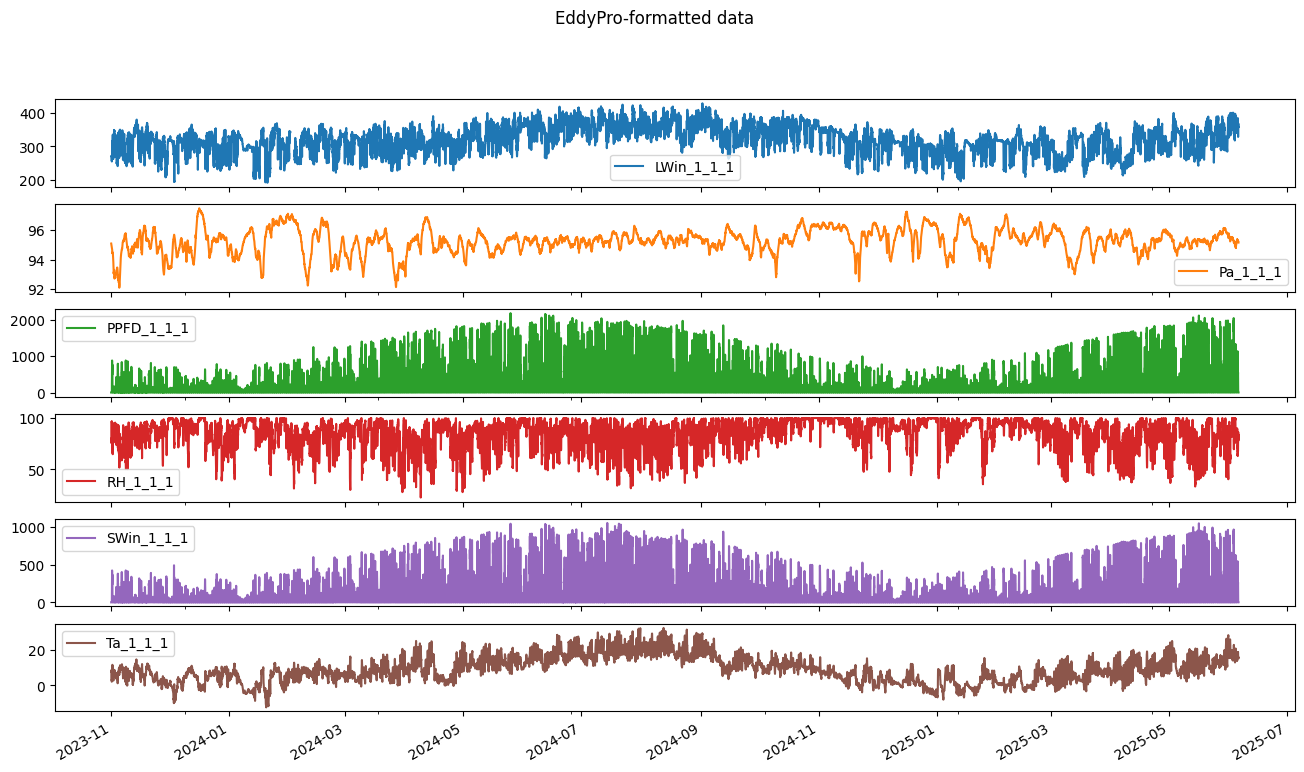

In [24]:
df_eddypro = pd.DataFrame(index=meteo_filled.index)
df_eddypro['TIMESTAMP_1'] = meteo_filled.index.strftime("%Y-%m-%d %H%M")
df_eddypro['LWin_1_1_1'] = meteo_filled['lw_in']
df_eddypro['Pa_1_1_1'] = meteo_filled['pa']
df_eddypro['PPFD_1_1_1'] = meteo_filled['ppfd']
df_eddypro['RH_1_1_1'] = meteo_filled['rh']
df_eddypro['SWin_1_1_1'] = meteo_filled['sw_in']
df_eddypro['Ta_1_1_1'] = meteo_filled['ta']

# NaNs set to -9999
df_eddypro = df_eddypro.fillna(-9999)

indat = df_eddypro.replace(-9999, float('nan')) # needed otherwise impossible to visualize
indat.plot(x_compat=True, figsize=(16, 9), title="EddyPro-formatted data", subplots=True);
df_eddypro

Export the 6 variables for eddypro

In [25]:
# Define column names
column_names = df_eddypro.columns.tolist()

# Define second line of the header (units)
header_units = ["yyyy-mm-dd HHMM", "W+1m-2", "kPa", "umol+1m-2s-1", "%", "W+1m-2", "C"]

# Define CSV filename
output_file = "11.2_CH-TAN_2023-25_6meteo_eddypro_format.csv"

# Open file and write headers manually
with open(output_file, "w") as f:
    f.write(",".join(column_names) + "\n")  # First header row (column names)
    f.write(",".join(header_units) + "\n")  # Second header row (units)

# Now append the DataFrame content without the header (to avoid duplication)
df_eddypro.to_csv(output_file, mode="a", index=False, header=False)

print(f"Eddypro-formatted data exported to {output_file} with units in the second row.")

Eddypro-formatted data exported to 11.2_CH-TAN_2023-25_6meteo_eddypro_format.csv with units in the second row.


# End of notebook

In [26]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2025-08-25 17:50:43
